# MNIST with NN

In [2]:
import numpy as np
import pasta as ps
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Input

from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split

In [3]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [4]:
show = np.random.randint(0,X_train.shape[0],10)
show

array([35847, 31287, 30276, 47930, 26850, 58658, 53902, 28938, 36400,
        6847])

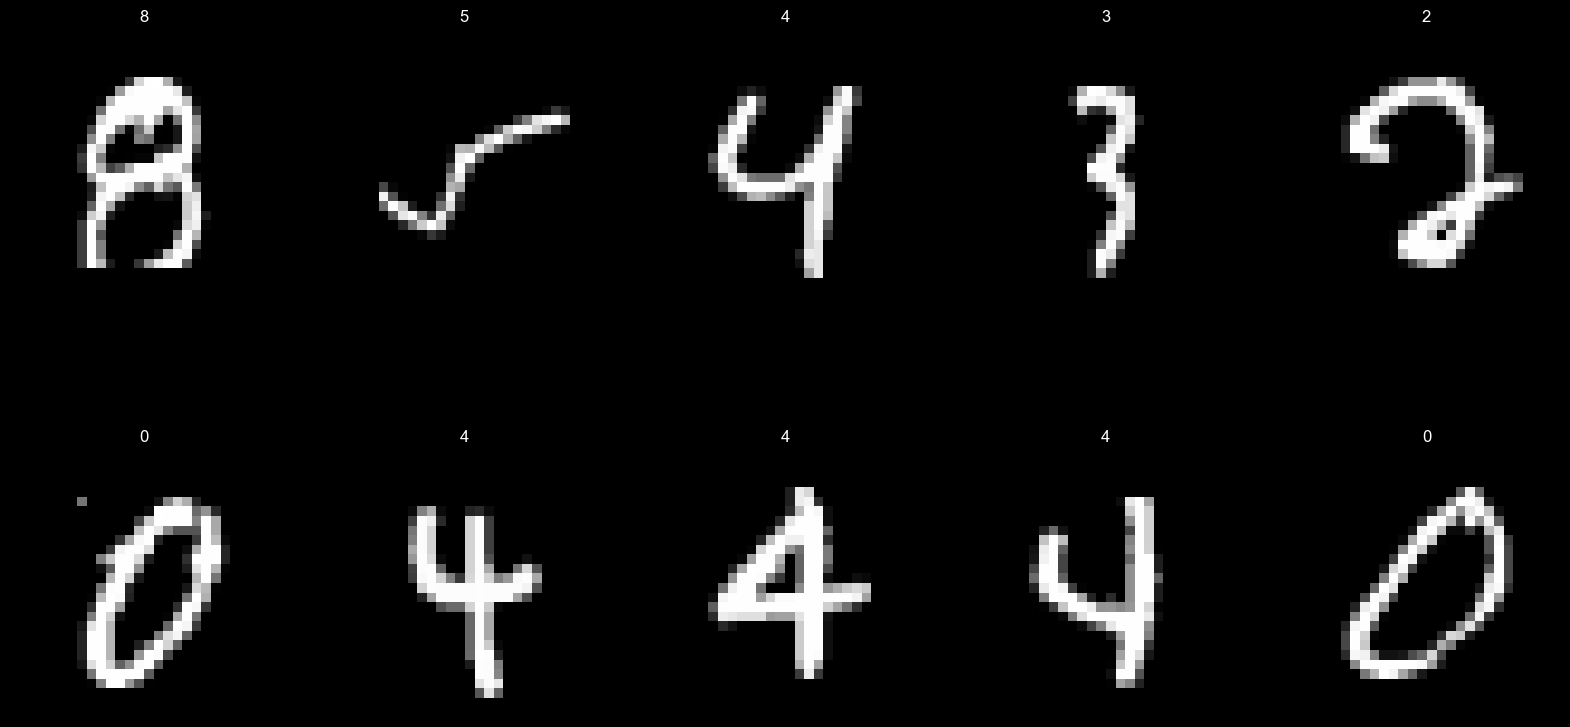

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[show[i]].reshape(28, 28), cmap="gray")
    ax.set_title(y_train[show[i]])
    ax.axis("off")

plt.show()

In [6]:
train_dist = np.unique(y_train, return_counts=True)
num_train, count_train = train_dist

In [7]:
num_train, count_train

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949],
       dtype=int64))

<BarContainer object of 10 artists>

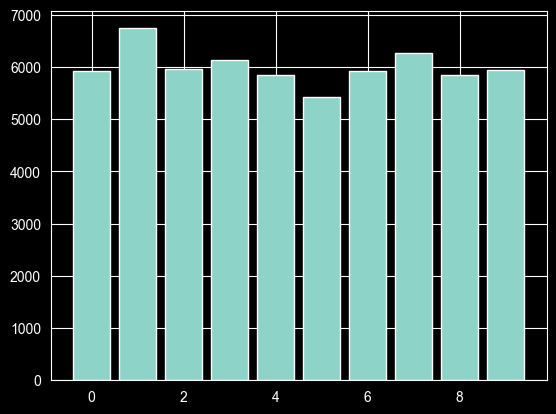

In [8]:
plt.bar(num_train, count_train)

In [9]:
test_dist = np.unique(y_test, return_counts=True)
num_test, count_test = test_dist

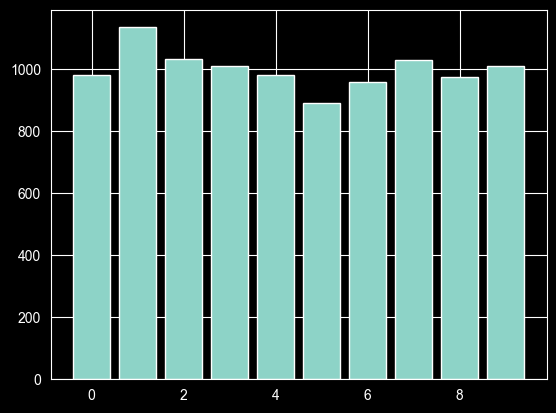

In [10]:
plt.bar(num_test, count_test)
plt.show()

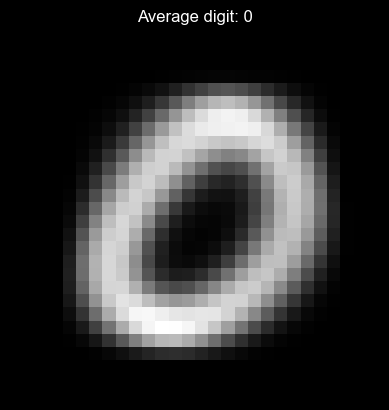

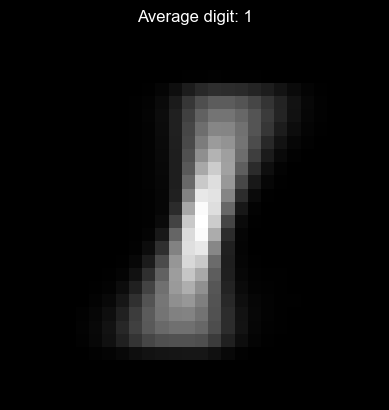

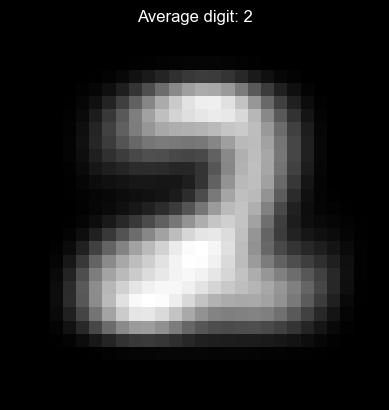

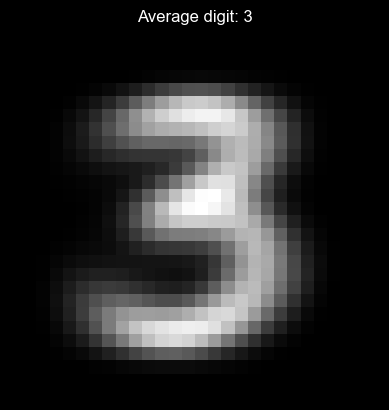

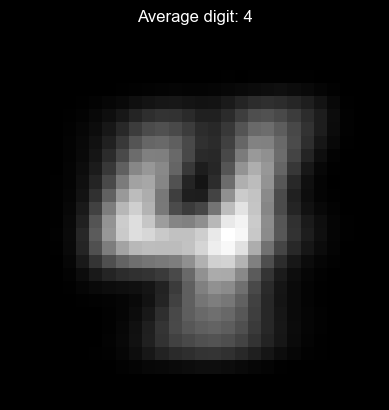

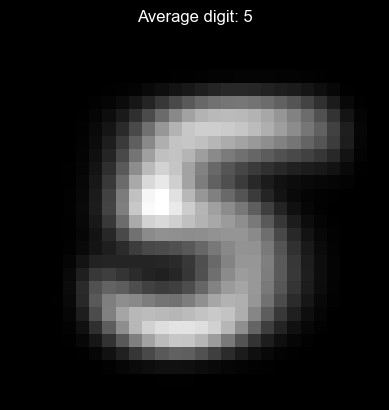

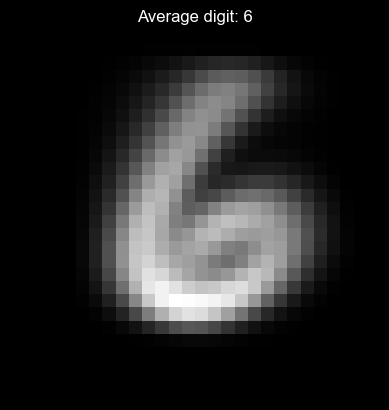

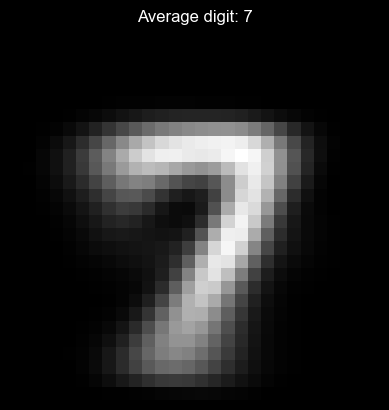

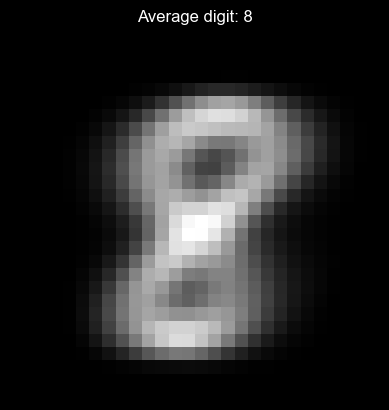

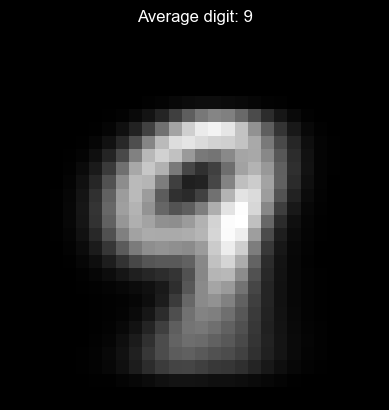

In [11]:
#We average the images to **see the typical/common shape and pixel pattern of that digit across the whole class**.

for digit in range(10):
    mean_image = X_train[y_train == digit].mean(axis=0)

    plt.figure()
    plt.imshow(mean_image.reshape(28, 28), cmap="gray")
    plt.title(f"Average digit: {digit}")
    plt.axis("off")
    plt.show()

In [12]:
X_train = X_train/255.0
X_test = X_test/255.0

In [13]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', solver='adam',
                    alpha=1e-4, batch_size=128, learning_rate_init=1e-3,
                    max_iter=50, early_stopping=True, validation_fraction=0.1,
                    n_iter_no_change=5)

In [14]:
X_train = X_train.reshape(-1,784)
X_test = X_test.reshape(-1,784)

In [15]:
X_train.shape

(60000, 784)

In [16]:
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', solver='adam',
                    alpha=1e-4, batch_size=128, learning_rate_init=1e-3,
                    max_iter=50, early_stopping=True, validation_fraction=0.1,
                    n_iter_no_change=5)

In [17]:
mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",128
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",50
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",5
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updatin

In [18]:
len(mlp.coefs_)

3

In [19]:
len(mlp.intercepts_)


3

In [20]:
trainable_params = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)

In [21]:
trainable_params

235146

In [22]:
mlp.best_validation_score_

0.9773333333333334

In [23]:
from sklearn.metrics import accuracy_score
y_pred = mlp.predict(X_test)
proba = mlp.predict_proba(X_test)          # shape (10000, 10): probability of each class

train_acc = accuracy_score(y_train, mlp.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
print(f'Train accuracy : {train_acc:.4f}')
print(f'Test  accuracy : {test_acc:.4f}')
print(f'Test  error    : {1 - test_acc:.4f}  ->  {int((1 - test_acc) * len(y_test))} misclassified images')

Train accuracy : 0.9950
Test  accuracy : 0.9789
Test  error    : 0.0211  ->  211 misclassified images


In [24]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9778    0.9908    0.9843       980
           1     0.9894    0.9903    0.9899      1135
           2     0.9881    0.9690    0.9785      1032
           3     0.9716    0.9812    0.9764      1010
           4     0.9786    0.9786    0.9786       982
           5     0.9732    0.9776    0.9754       892
           6     0.9905    0.9833    0.9869       958
           7     0.9881    0.9698    0.9789      1028
           8     0.9712    0.9682    0.9697       974
           9     0.9592    0.9792    0.9691      1009

    accuracy                         0.9789     10000
   macro avg     0.9788    0.9788    0.9788     10000
weighted avg     0.9790    0.9789    0.9789     10000



In [25]:
cm = confusion_matrix(y_test, y_pred)


<Axes: >

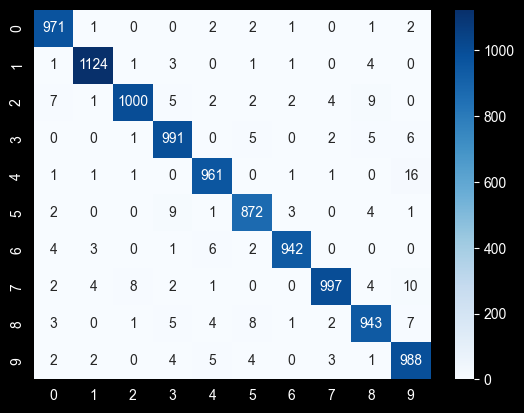

In [26]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")


In [28]:
from sklearn.metrics import roc_curve,auc
from sklearn.preprocessing import label_binarize, OneHotEncoder

In [30]:
encoder = OneHotEncoder(sparse_output=False)
y_test_s = encoder.fit_transform(y_test.reshape(-1,1))

In [31]:
y_test_s

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [33]:
y_pred = mlp.predict_proba(X_test)

In [35]:
y_pred

array([[1.32632505e-08, 2.31989527e-08, 2.50395557e-06, ...,
        9.99987999e-01, 2.78918310e-07, 2.06421563e-06],
       [2.63931774e-09, 5.22206284e-04, 9.99475352e-01, ...,
        5.95097782e-12, 1.46384308e-09, 6.87758875e-14],
       [7.77951794e-09, 9.99980865e-01, 1.86526375e-07, ...,
        1.25391618e-05, 1.19172453e-07, 1.86937676e-09],
       ...,
       [1.57784454e-13, 3.67442164e-11, 1.20858361e-14, ...,
        2.23563241e-08, 8.70919907e-09, 5.75367501e-06],
       [1.30402068e-11, 2.05226725e-15, 2.47434323e-14, ...,
        1.84989450e-13, 1.15547279e-05, 2.00816357e-14],
       [1.92414362e-10, 1.66912849e-13, 4.68971305e-10, ...,
        2.18567509e-18, 5.08750805e-14, 2.32207483e-11]])

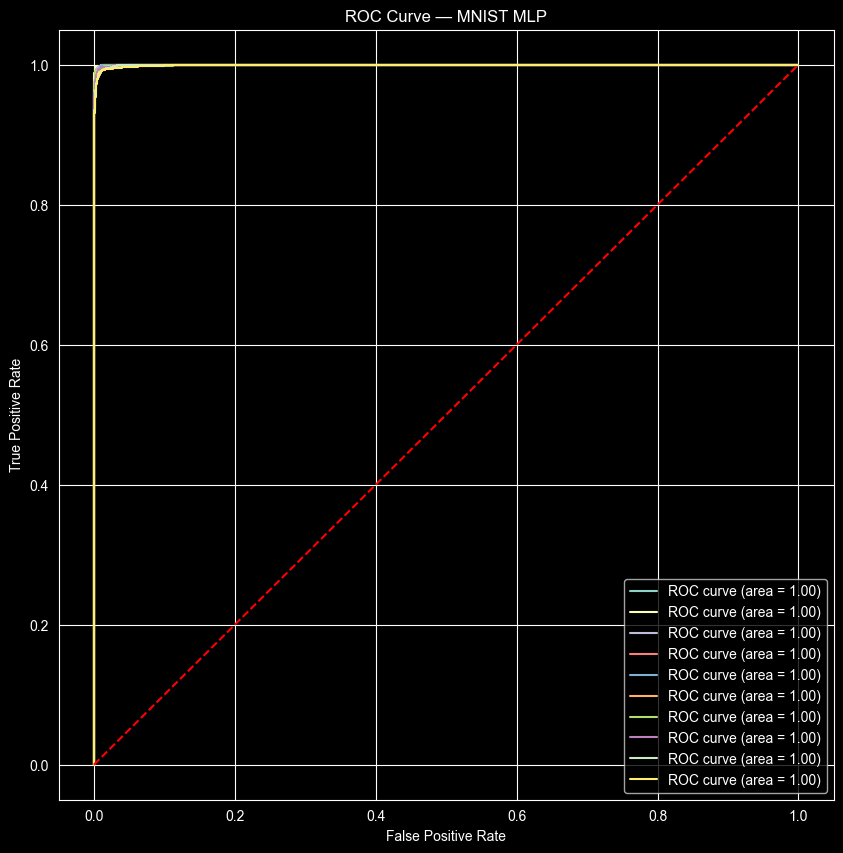

In [44]:
n = np.unique(y_test, return_counts=False)
n = len(n)
plt.figure(figsize=(10,10))
for i in range(10):
    fpr , tpr, threshold = roc_curve(y_test_s[:,i],y_pred[:,i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label='ROC curve (area = %0.2f)' % roc_auc,
    )

plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — MNIST MLP")
plt.legend()
plt.show()

10